In [1]:
import sys
import os
import time
from lightkurve import search_targetpixelfile
from lightkurve import TessTargetPixelFile
import lightkurve as lk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from keras.models import load_model
from keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Conv1D, MaxPooling1D, Flatten
from wotan import slide_clip
from wotan import transit_mask, flatten
from astropy.stats import sigma_clip
from astropy import units as u
import csv
import shutil
from scipy.interpolate import interp1d
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import make_forecasting_frame
from tsfresh.utilities.dataframe_functions import impute
from statsmodels.tsa.seasonal import seasonal_decompose
from multiprocessing import Pool
import multiprocessing
import numpy as np
import pandas as pd
import lightkurve as lk
from scipy.signal import find_peaks
from astropy.timeseries import BoxLeastSquares
from scipy.interpolate import interp1d

In [2]:
%matplotlib inline

In [5]:
value_df = 1000
cwd = os.getcwd()
dirname = cwd[len(cwd)-len("Satellite Datasets"):len(cwd)]
if(dirname != 'Satellite Datasets'):
    os.chdir('./Satellite Datasets')
star_check = pd.read_csv("exoplanet_star_trend_flux.csv")
star_check = star_check.dropna()
star_check = star_check.drop(['tid'],axis=1)
star_check_y = star_check[['confirmed_planet']]
star_check = star_check.reset_index().drop('index',axis=1)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(star_check.drop('confirmed_planet',axis=1),star_check[['confirmed_planet']], test_size=0.1, random_state=42)

In [60]:
from tensorflow.keras.layers import Conv1D, LeakyReLU

model = Sequential([
    Conv1D(filters=16, kernel_size=5, activation='relu', input_shape=(1000,1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [61]:
model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/15
255/255 [==============================] - 3s 11ms/step - loss: 0.6840 - accuracy: 0.5748 - val_loss: 0.6804 - val_accuracy: 0.5806
Epoch 2/15
255/255 [==============================] - 3s 11ms/step - loss: 0.6809 - accuracy: 0.5807 - val_loss: 0.6804 - val_accuracy: 0.5806
Epoch 3/15
255/255 [==============================] - 3s 10ms/step - loss: 0.6809 - accuracy: 0.5810 - val_loss: 0.6809 - val_accuracy: 0.5806
Epoch 4/15
255/255 [==============================] - 3s 10ms/step - loss: 0.6803 - accuracy: 0.5810 - val_loss: 0.6813 - val_accuracy: 0.5806
Epoch 5/15
255/255 [==============================] - 3s 10ms/step - loss: 0.7023 - accuracy: 0.5800 - val_loss: 0.6809 - val_accuracy: 0.5806
Epoch 6/15
255/255 [==============================] - 3s 10ms/step - loss: 0.6800 - accuracy: 0.5809 - val_loss: 0.6802 - val_accuracy: 0.5806
Epoch 7/15
255/255 [==============================] - 3s 11ms/step - loss: 0.6800 - accuracy: 0.5809 - val_loss: 0.6801 - val_accuracy: 0.5806

1/1 [==============================] - 0s 30ms/step


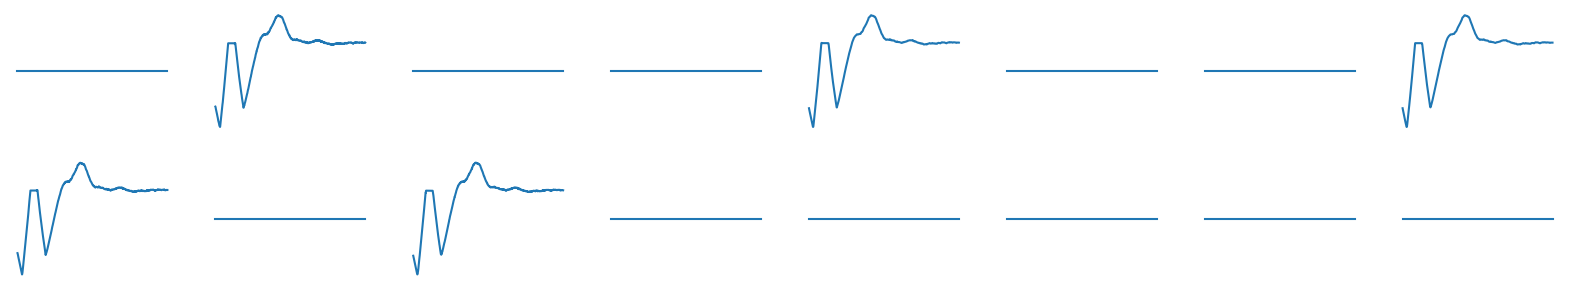

In [63]:
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np


x_sample = X_test.iloc[0].to_numpy().reshape(1,1000)

layer_outputs = [model.layers[0].output]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

feature_maps = activation_model.predict(x_sample)

first_feature_map = feature_maps[0]
plt.figure(figsize=(20, 15))
for i in range(first_feature_map.shape[-1]):
    plt.subplot(8, 8, i+1)  
    plt.plot(first_feature_map[:, i:i+1])
    plt.axis('off')
plt.show()


In [56]:
model.layers[0]